In [2]:
# STEP 1- Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# STEP 2- Load Dataset

df = pd.read_csv("/content/drive/MyDrive/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# STEP 3- Basic Exploration

df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
# Step 3 Conclusion
# The dataset contains 10,000 customers
# There are 14 features
# No missing values are present
# Data includes both numerical and categorical variables
#The target column is 'Exited'(customer churn)

In [10]:
# Step 4- Target Variable Analysis (Churn Analysis)
# Goal:
  #1. See how many customers churned vs stayed
  #2. Calculate churn percentage
  #3. Visualize the distribution

In [11]:
#4.1 Check Churn Distribution
# First check how many customers left the bank.

df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [12]:
# Customer stayed - 7963
# Customer churned - 2037

In [13]:
#4.2 - Calculate Churn Percentage

df['Exited'].value_counts(normalize=True)*100

,proportion
Exited,
0,79.63
1,20.37


In [14]:
# Insight :
 # 80% customers stayed
 # 20% customers churned

# This tells us churn is moderate but important

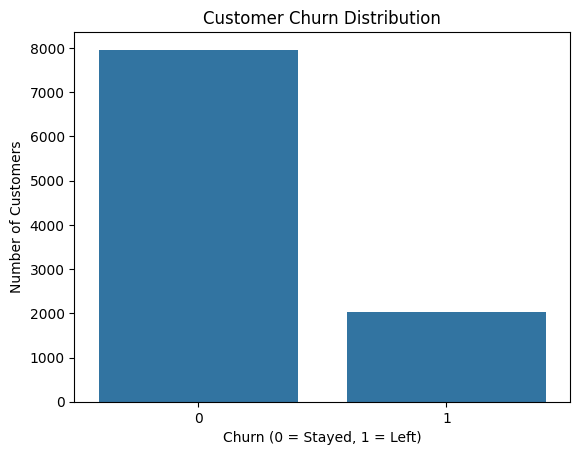

In [15]:
#4.3 Visualize Churn Distribution

sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()

**Insight:**

Approximately 20% of customers have churned, while about 80% remain with the bank. This indicates that customer churn is a significant issue and requires further analysis to identify the factors contributing to churn.

In [16]:
# Step 5- Age vs Churn Analysis
# Goal of this step:
  #1. Compare age of churned vs retained customers
  #2. Check if older or younger customers churn more
  #3. Visualize the relationship

In [17]:
#5.1 Check Churn by Average Age

df.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


In [18]:
# Meaning Churn status : stayed ~ 37(avg age)
 #                       churned ~ 45(avg age)

# This suggests older customers churn more frequently.

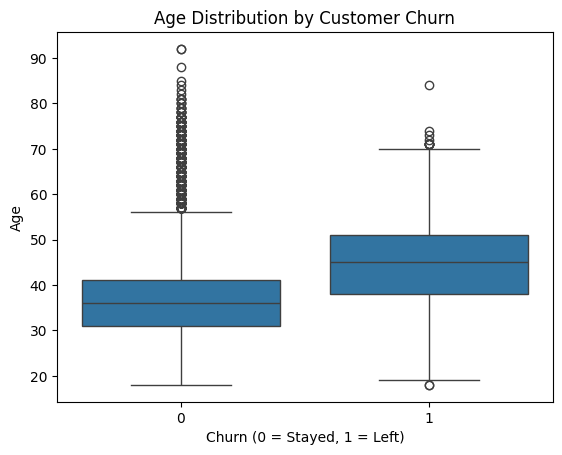

In [19]:
#5.2 Boxplot (A boxplot shows the distribution of age for churned vs non-churned customers.)

sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age Distribution by Customer Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Age")
plt.show()

**Insight:**

The boxplot shows that customers who churn tend to be older than those who remain with the bank. The median age of churned customers is significantly higher, suggesting that middle-aged and older customers are more likely to leave the bank.

**Why This Insight Matters for Business**:

Banks could:

	•	target older customers with loyalty programs
	•	offer special financial products
	•	improve customer engagement for older segments


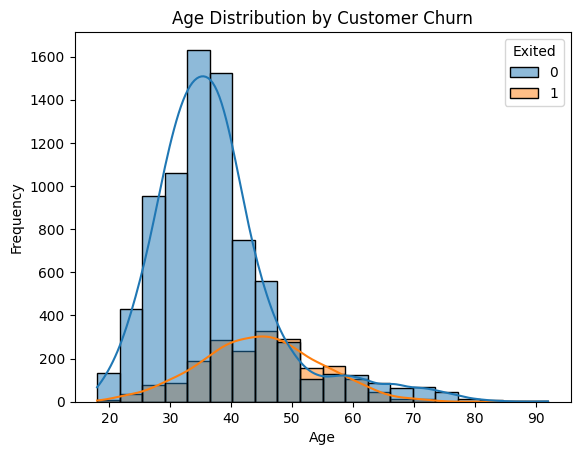

In [20]:
#5.3 Histogram by Churn

sns.histplot(x='Age', data=df, hue='Exited', kde=True, bins=20)
plt.title("Age Distribution by Customer Churn")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insight :**

The age distribution shows that churn is more common among middle-aged customers, particularly between 40 and 60 years old. Younger customers tend to remain with the bank, while older customers are more likely to leave.

⸻

**Why This Insight Is Valuable**

Banks could:

	•	create retention strategies for customers aged 40+
	•	offer personalized financial products
	•	improve customer engagement for mid-career professionals

In [21]:
#Step 6- Geography vs Churn
# Goal :
  #1) See how churn varies across countries
  #2) Calculate churn rate by geography
  #3) Visualize the results

In [22]:
#6.1 Count Customers by Country

df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [23]:
#6.2 Churn Count by Country

df.groupby('Geography')['Exited'].value_counts()

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64

In [24]:
#6.3 Churn Rate by Country

df.groupby('Geography')['Exited'].mean()*100


,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


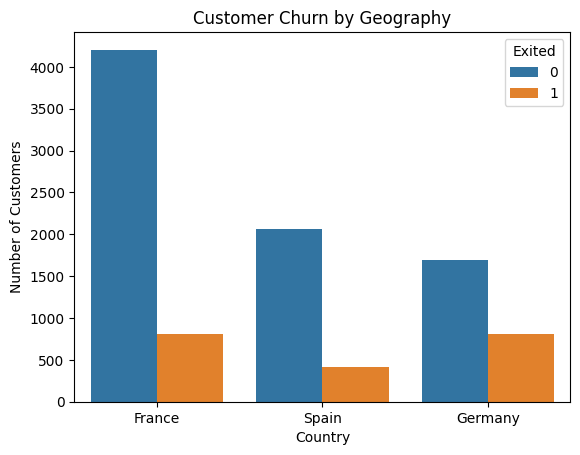

In [25]:
#6.4 Visualization

sns.countplot(x='Geography', data=df, hue='Exited')
plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

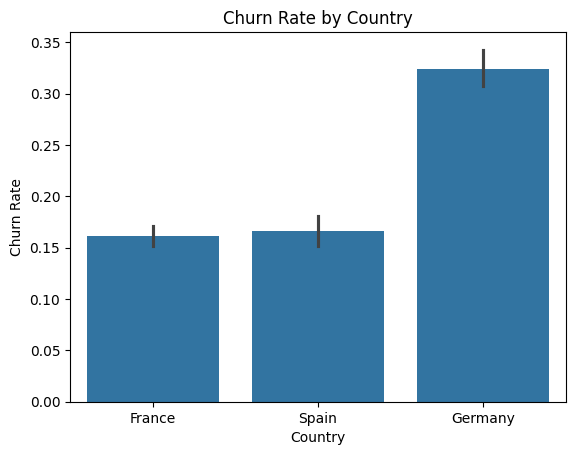

In [26]:
#6.5 Better Visualization (Churn rate)

sns.barplot(x='Geography', y='Exited', data=df)
plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate")
plt.show()

**Key Insight :**

The analysis shows that customers in Germany have a significantly higher churn rate compared to customers in France and Spain. This suggests that geographic factors may strongly influence customer retention, and the bank may need to investigate potential issues affecting German customers.

⸻

**Possible Business Reasons :**

Germany might have higher churn because of:

	•	stronger banking competition
	•	different customer expectations
	•	lower customer satisfaction
	•	product mismatch

⸻

**Business Recommendation :**

The bank should:

	•	investigate customer experience in Germany
	•	introduce retention programs
	•	offer personalized banking products


In [27]:
#Step 7- Active Member vs Churn
# Goal:
	 #Check whether inactive customers churn more.


df['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [28]:
#7.2 Churn by Active Status

df.groupby('IsActiveMember')['Exited'].value_counts()

IsActiveMember  Exited
0               0         3547
                1         1302
1               0         4416
                1          735
Name: count, dtype: int64

In [29]:
#7.3 Churn Rate by Activity

df.groupby('IsActiveMember')['Exited'].mean()*100

,Exited
IsActiveMember,
0,26.850897
1,14.269074


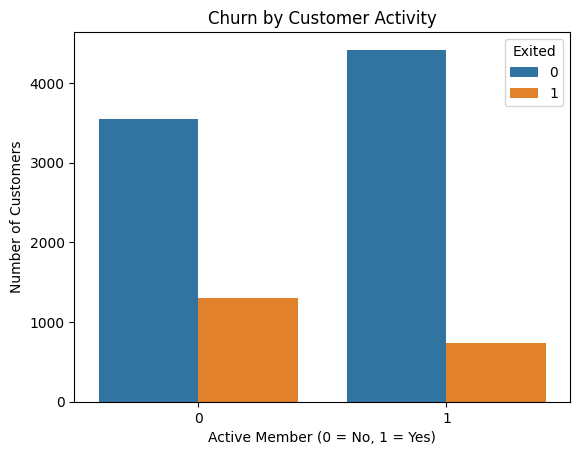

In [30]:
#7.4 Visualization

sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title("Churn by Customer Activity")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

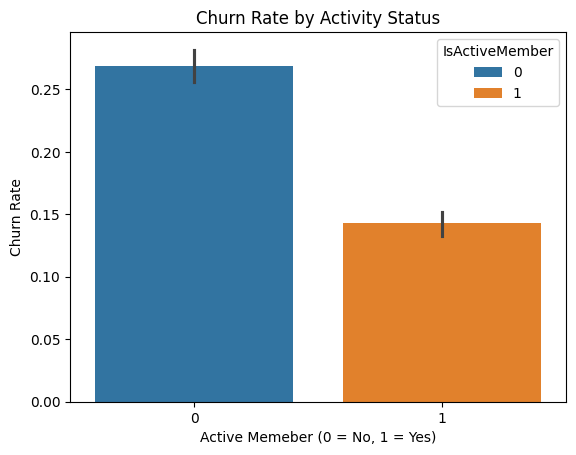

In [31]:
#7.5 Churn Rate Visualization

sns.barplot(x='IsActiveMember', y='Exited', hue='IsActiveMember' ,data=df)
plt.title("Churn Rate by Activity Status")
plt.xlabel("Active Memeber (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")
plt.show()

**Key Insight :**

Inactive customers are significantly more likely to churn than active customers. The churn rate among inactive customers is nearly twice as high as that of active customers, suggesting that customer engagement plays a major role in retention.

⸻

**Business Recommendation :**

The bank should:

	•	encourage customer engagement
	•	promote mobile banking usage
	•	offer loyalty rewards for active usage

In [32]:
#Step 8- Number of Products vs Churn

df['NumOfProducts'].value_counts()




,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [33]:
#8.2 Churn by Number of Products

df.groupby('NumOfProducts')['Exited'].value_counts()

NumOfProducts  Exited
1              0         3675
               1         1409
2              0         4242
               1          348
3              1          220
               0           46
4              1           60
Name: count, dtype: int64

In [34]:
#8.3 Churn Rate by Products

df.groupby('NumOfProducts')['Exited'].mean()*100

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


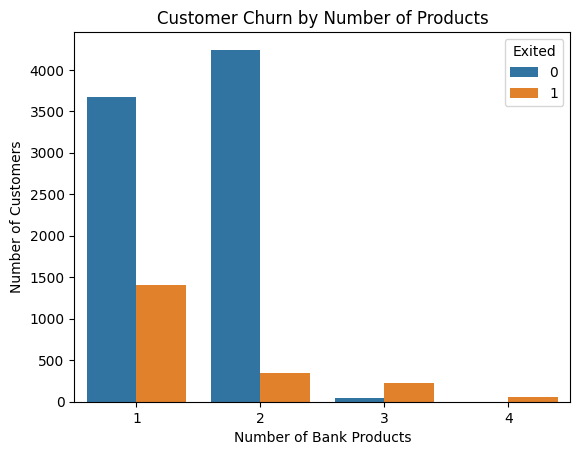

In [35]:
#8.4 Visualization

sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Bank Products")
plt.ylabel("Number of Customers")
plt.show()

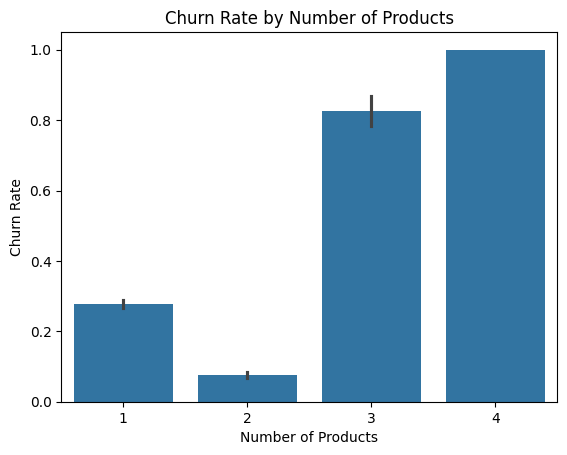

In [36]:
#8.5 Churn Rate Visualization

sns.barplot(x='NumOfProducts', y='Exited', data=df)
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.show()

**Key Insight :**

Customers with two bank products show the lowest churn rate, indicating stronger engagement with the bank. However, customers with three or four products have an unexpectedly high churn rate, suggesting potential dissatisfaction or product overload.

⸻

**Business Interpretation :**

Customers with many products might:

	•	feel overcharged
	•	experience complex banking services
	•	move to competitors offering better bundled services


In [37]:
#Step 9- Balance vs Churn
#Goal:
	#•	Check whether customers with higher balances churn more
	#•	Analyze balance distribution
	#•	Visualize the relationship



In [38]:
#9.1 Average Balance by Churn

df.groupby('Exited')['Balance'].mean()

,Balance
Exited,
0,72745.296779
1,91108.539337


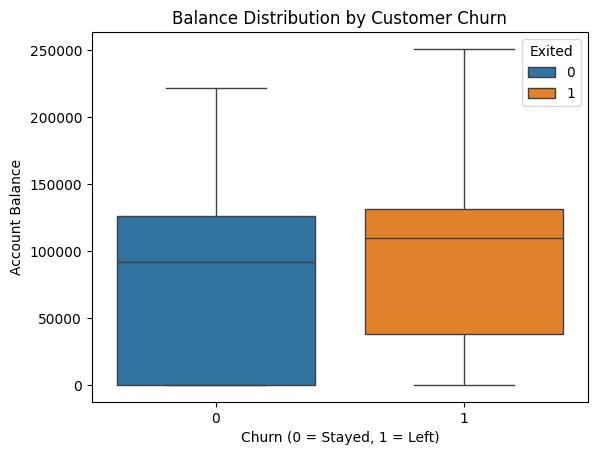

In [39]:
#9.2 Balance Distribution

sns.boxplot(x='Exited', y='Balance',hue='Exited', data=df)
plt.title("Balance Distribution by Customer Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Account Balance")

plt.show()

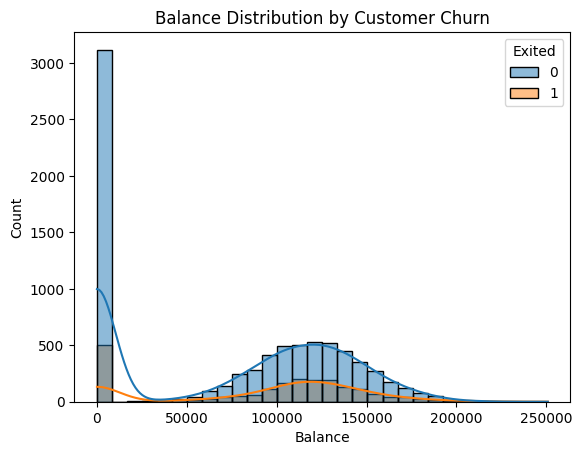

In [40]:
#9.3 Histogram for Balance
   #This helps identify:
	   #•	balance patterns
	   #•	clusters
	   #•	whether high-balance customers churn more.

sns.histplot(data=df, x='Balance', hue='Exited', bins=30, kde=True)

plt.title("Balance Distribution by Customer Churn")
plt.show()


**Insight:**

The analysis shows that customers who churn tend to have higher account balances compared to retained customers. Additionally, a large number of customers maintain zero balance accounts, indicating inactive or dormant accounts. Churn is more common among customers with mid-to-high balances, suggesting that valuable customers may be moving to competing banks offering better financial services.

⸻

**Business Insights:**

The bank should focus on retaining high-value customers by:

	•	offering premium services
	•	improving investment and savings products
	•	providing loyalty benefits for high-balance customers


In [41]:
#Step 10- Credit Score vs Churn

df.groupby('Exited')['CreditScore'].mean()

,CreditScore
Exited,
0,651.853196
1,645.351497


In [42]:
#Step 11- Tenure vs Churn

df.groupby('Exited')['Tenure'].mean()


,Tenure
Exited,
0,5.033279
1,4.932744


In [43]:
#Step 12- Salary vs Churn

df.groupby('Exited')['EstimatedSalary'].mean()

,EstimatedSalary
Exited,
0,99738.391772
1,101465.677531


**Insight:**

The analysis shows that credit score, tenure, and estimated salary have minimal differences between churned and retained customers. This suggests that financial capability or income level does not strongly influence customer churn. Instead, churn appears to be more closely related to factors such as customer activity, product usage, age, and geographic location.

In [44]:
#Step 13- Gender vs Churn

gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn



,Exited
Gender,
Female,25.071539
Male,16.455928


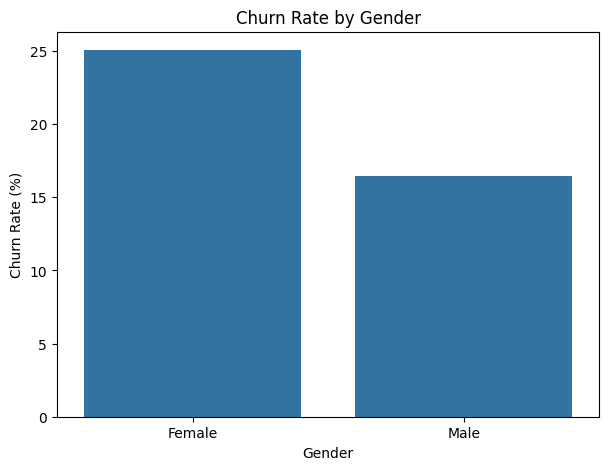

In [45]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.show()

In [46]:
pd.crosstab(df['Gender'], df['Exited'])

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


**Insight:**

Female customers have a higher churn rate (25.07%) compared with male customers (16.46%), indicating that female customers may represent a relatively higher-risk segment. Further analysis of other factors such as geography, age, activity status and product usage is required to understand the underlying reasons for this difference.



In [47]:
country_gender_churn = (
    df.groupby(['Geography', 'Gender'])['Exited']
      .mean()
      .mul(100)
      .reset_index()
)

country_gender_churn

,Geography,Gender,Exited
0,France,Female,20.344980
1,France,Male,12.713404
2,Germany,Female,37.552389
3,Germany,Male,27.811550
4,Spain,Female,21.212121
5,Spain,Male,13.112392


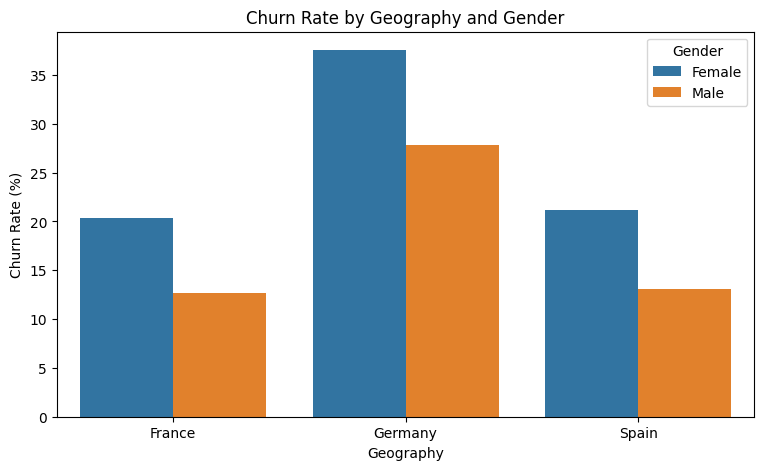

In [48]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=country_gender_churn,
    x='Geography',
    y='Exited',
    hue='Gender'
)

plt.title('Churn Rate by Geography and Gender')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Gender')
plt.show()

**Insight:**

Germany shows the highest churn rate for both female and male customers. Female customers have a higher churn rate than male customers across all three countries, with the gender gap being particularly noticeable in Germany. This suggests that Germany may require deeper investigation into customer engagement, product usage and demographic characteristics.

In [49]:
#Step 14- Credit Card vs Churn

credit_card_churn = df.groupby('HasCrCard')['Exited'].mean() * 100
credit_card_churn

,Exited
HasCrCard,
0,20.814941
1,20.184266


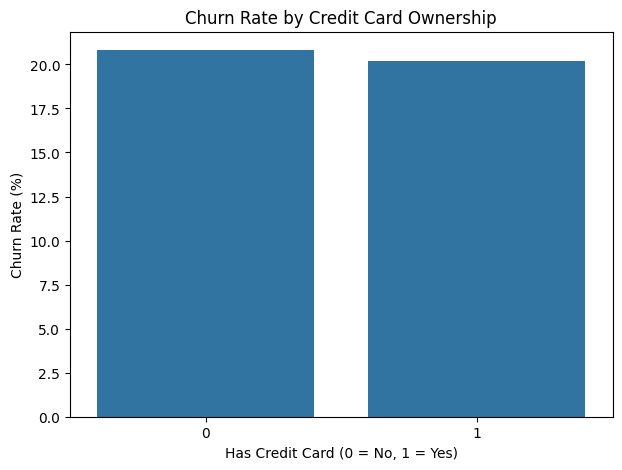

In [50]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=credit_card_churn.index,
    y=credit_card_churn.values
)

plt.title('Churn Rate by Credit Card Ownership')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')

plt.show()

**Insight:**

Customers without a credit card have a churn rate of 20.81%, compared with 20.18% among customers with a credit card. The difference is very small, suggesting that credit card ownership alone does not appear to be a strong indicator of customer churn.

In [51]:
#Step 15- Prodcuts * Activity * Churn

product_activity_churn = (
    df.groupby(['NumOfProducts', 'IsActiveMember'])['Exited']
      .mean()
      .mul(100)
      .reset_index()
)

product_activity_churn

,NumOfProducts,IsActiveMember,Exited
0,1,0,36.652122
1,1,1,18.923137
2,2,0,9.888060
3,2,1,5.560098
4,3,0,88.235294
5,3,1,75.221239
6,4,0,100.000000
7,4,1,100.000000


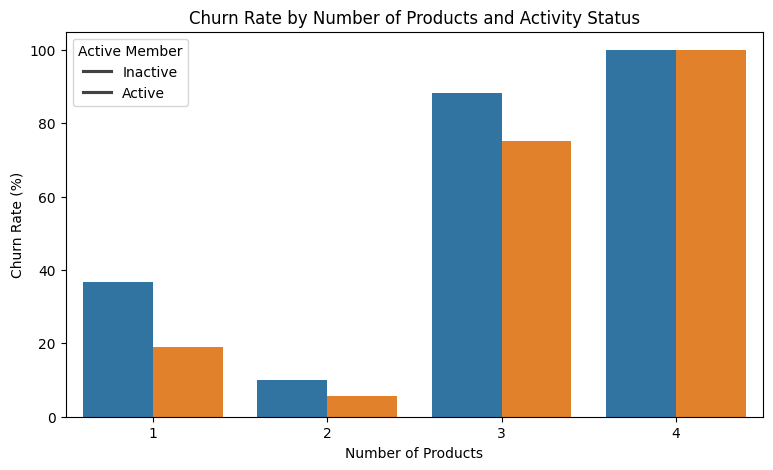

In [52]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=product_activity_churn,
    x='NumOfProducts',
    y='Exited',
    hue='IsActiveMember'
)

plt.title('Churn Rate by Number of Products and Activity Status')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.legend(
    title='Active Member',
    labels=['Inactive', 'Active']
)

plt.show()

In [53]:
product_activity_count = (
    df.groupby(['NumOfProducts', 'IsActiveMember'])
      .size()
      .reset_index(name='Customer_Count')
)

product_activity_count

,NumOfProducts,IsActiveMember,Customer_Count
0,1,0,2521
1,1,1,2563
2,2,0,2144
3,2,1,2446
4,3,0,153
5,3,1,113
6,4,0,31
7,4,1,29


In [54]:
product_activity_summary = (
    df.groupby(['NumOfProducts', 'IsActiveMember'])
      .agg(
          Customer_Count=('Exited', 'size'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

product_activity_summary['Churn_Rate'] *= 100

product_activity_summary

,NumOfProducts,IsActiveMember,Customer_Count,Churn_Rate
0,1,0,2521,36.652122
1,1,1,2563,18.923137
2,2,0,2144,9.888060
3,2,1,2446,5.560098
4,3,0,153,88.235294
5,3,1,113,75.221239
6,4,0,31,100.000000
7,4,1,29,100.000000


**Insight:**

Customer activity is consistently associated with lower churn across the 1–3 product segments. Customers with 1 product show a substantial churn difference between inactive (36.65%) and active members (18.92%). The 3-product segment has exceptionally high churn rates for both inactive (88.24%) and active (75.22%) customers, suggesting that this segment requires further investigation. The 4-product segment shows 100% churn but contains only 60 customers, so this result should be interpreted cautiously due to the small sample size.

In [55]:
#Step 16- Age Segmentation

bins = [18, 25, 35, 45, 55, 65, 100]

labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '66+'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [56]:
age_group_churn = (
    df.groupby('AgeGroup', observed=True)['Exited']
      .mean()
      .mul(100)
)

age_group_churn

,Exited
AgeGroup,
18-25,7.528642
26-35,8.498024
36-45,19.619914
46-55,50.572082
56-65,48.320896
66+,13.257576


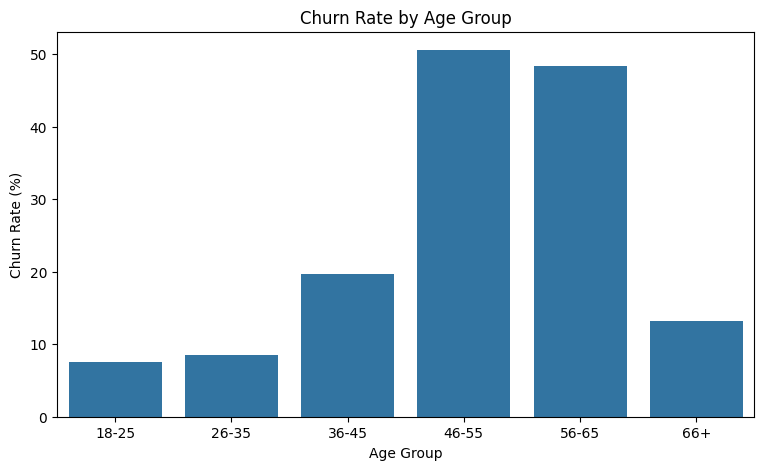

In [57]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=age_group_churn.index,
    y=age_group_churn.values
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()

**Insight:**

Churn rates vary considerably across age groups. Customers aged 46–55 and 56–65 show substantially higher churn rates than younger customers, with the 46–55 group having the highest observed churn rate. This indicates that age may be an important factor associated with customer churn. Customer counts should also be considered before drawing final conclusions.

In [58]:
age_group_summary = (
    df.groupby('AgeGroup', observed=True)
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

age_group_summary['Churn_Rate'] *= 100

age_group_summary

,AgeGroup,Customer_Count,Churned_Customers,Churn_Rate
0,18-25,611,46,7.528642
1,26-35,3542,301,8.498024
2,36-45,3736,733,19.619914
3,46-55,1311,663,50.572082
4,56-65,536,259,48.320896
5,66+,264,35,13.257576


**Insight:**

Age is strongly associated with customer churn in this dataset. Churn remains relatively low among customers below 36 years but increases sharply from the 36–45 age group onward. Customers aged 46–55 have the highest churn rate at 50.57%, followed closely by the 56–65 group at 48.32%. These segments represent important high-risk customer groups that should be investigated further for underlying behavioral and engagement factors.

In [59]:
#Step 17- Age vs Activity Analysis

age_activity_churn = (
    df.groupby(['AgeGroup', 'IsActiveMember'], observed=True)['Exited']
      .mean()
      .mul(100)
      .reset_index()
)

age_activity_churn

,AgeGroup,IsActiveMember,Exited
0,18-25,0,11.111111
1,18-25,1,4.334365
2,26-35,0,10.804598
3,26-35,1,6.270810
4,36-45,0,24.215938
5,36-45,1,14.628699
6,46-55,0,63.609023
7,46-55,1,37.151703
8,56-65,0,93.854749
9,56-65,1,25.490196


**Insight:**

Customer activity shows a strong association with churn, particularly among older age groups. The churn rate for inactive customers aged 46–55 is 63.61%, compared with 37.15% for active customers. The difference is even more pronounced among customers aged 56–65, where churn is 93.85% for inactive customers versus 25.49% for active customers. This suggests that inactive older customers may represent a critical high-risk segment for retention efforts.

In [60]:
age_activity_summary = (
    df.groupby(['AgeGroup', 'IsActiveMember'], observed=True)
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

age_activity_summary['Churn_Rate'] *= 100

age_activity_summary

,AgeGroup,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate
0,18-25,0,288,32,11.111111
1,18-25,1,323,14,4.334365
2,26-35,0,1740,188,10.804598
3,26-35,1,1802,113,6.270810
4,36-45,0,1945,471,24.215938
5,36-45,1,1791,262,14.628699
6,46-55,0,665,423,63.609023
7,46-55,1,646,240,37.151703
8,56-65,0,179,168,93.854749
9,56-65,1,357,91,25.490196


In [61]:
#Step 18- High-Risk Segment Analysis

high_risk_age = df[df['AgeGroup'].isin(['46-55', '56-65'])]

high_risk_summary = (
    high_risk_age
    .groupby(['AgeGroup', 'Geography', 'IsActiveMember'], observed=True)
    .agg(
        Customer_Count=('Exited', 'size'),
        Churned_Customers=('Exited', 'sum'),
        Churn_Rate=('Exited', 'mean')
    )
    .reset_index()
)

high_risk_summary['Churn_Rate'] *= 100

high_risk_summary.sort_values(
    'Churn_Rate',
    ascending=False
)

,AgeGroup,Geography,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate
8,56-65,Germany,0,69,66,95.652174
6,56-65,France,0,77,72,93.506494
10,56-65,Spain,0,33,30,90.909091
2,46-55,Germany,0,225,174,77.333333
4,46-55,Spain,0,146,87,59.589041
0,46-55,France,0,294,162,55.102041
3,46-55,Germany,1,178,96,53.932584
9,56-65,Germany,1,79,30,37.974684
1,46-55,France,1,303,103,33.993399
5,46-55,Spain,1,165,41,24.848485


**Insight:**

The interaction between age, geography and activity reveals distinct high-risk customer segments. The 56–65 inactive segment in Germany has the highest churn rate at 95.65%, with 66 of 69 customers churning. However, the 46–55 inactive segment in Germany has a larger absolute number of churned customers (174), indicating greater potential business impact. Therefore, both churn rate and churned customer volume should be considered when prioritizing retention strategies.

In [62]:
#Step 19- Important Analysis

churned_segment = (
    df[df['Exited'] == 1]
    .groupby(['AgeGroup', 'Geography', 'IsActiveMember'], observed=True)
    .size()
    .reset_index(name='Churned_Customers')
    .sort_values('Churned_Customers', ascending=False)
)

churned_segment

,AgeGroup,Geography,IsActiveMember,Churned_Customers
12,36-45,France,0,191
14,36-45,Germany,0,182
20,46-55,Germany,0,174
18,46-55,France,0,162
15,36-45,Germany,1,115
13,36-45,France,1,105
19,46-55,France,1,103
16,36-45,Spain,0,98
21,46-55,Germany,1,96
22,46-55,Spain,0,87


In [63]:
total_churned = df['Exited'].sum()

churned_segment['Churn_Share'] = (
    churned_segment['Churned_Customers'] / total_churned * 100
)

churned_segment

,AgeGroup,Geography,IsActiveMember,Churned_Customers,Churn_Share
12,36-45,France,0,191,9.376534
14,36-45,Germany,0,182,8.934708
20,46-55,Germany,0,174,8.541973
18,46-55,France,0,162,7.952872
15,36-45,Germany,1,115,5.645557
13,36-45,France,1,105,5.154639
19,46-55,France,1,103,5.056456
16,36-45,Spain,0,98,4.810997
21,46-55,Germany,1,96,4.712813
22,46-55,Spain,0,87,4.270987


**Insight:**

The churn contribution analysis shows that churn is concentrated among middle-aged inactive customers, particularly in France and Germany. The four largest segments—36–45 France inactive, 36–45 Germany inactive, 46–55 Germany inactive, and 46–55 France inactive—collectively account for approximately 34.8% of all churned customers. This indicates that targeted retention strategies focused on these segments could potentially address a substantial portion of customer churn.

In [64]:
#Step 20- Churn share/Top segments

balance_bins = [0, 50000, 100000, 150000, 200000, float('inf')]

balance_labels = [
    '0-50K',
    '50K-100K',
    '100K-150K',
    '150K-200K',
    '200K+'
]

df['BalanceGroup'] = pd.cut(
    df['Balance'],
    bins=balance_bins,
    labels=balance_labels,
    include_lowest=True
)

In [65]:
balance_summary = (
    df.groupby('BalanceGroup', observed=True)
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

balance_summary['Churn_Rate'] *= 100

balance_summary

,BalanceGroup,Customer_Count,Churned_Customers,Churn_Rate
0,0-50K,3692,526,14.247021
1,50K-100K,1509,300,19.880716
2,100K-150K,3830,987,25.770235
3,150K-200K,935,205,21.925134
4,200K+,34,19,55.882353


In [66]:
balance_activity_churn = (
    df.groupby(['BalanceGroup', 'IsActiveMember'], observed=True)['Exited']
      .mean()
      .mul(100)
      .reset_index()
)

balance_activity_churn

,BalanceGroup,IsActiveMember,Exited
0,0-50K,0,18.999438
1,0-50K,1,9.827496
2,50K-100K,0,26.890756
3,50K-100K,1,13.584906
4,100K-150K,0,33.493590
5,100K-150K,1,18.386108
6,150K-200K,0,29.462366
7,150K-200K,1,14.468085
8,200K+,0,42.105263
9,200K+,1,73.333333


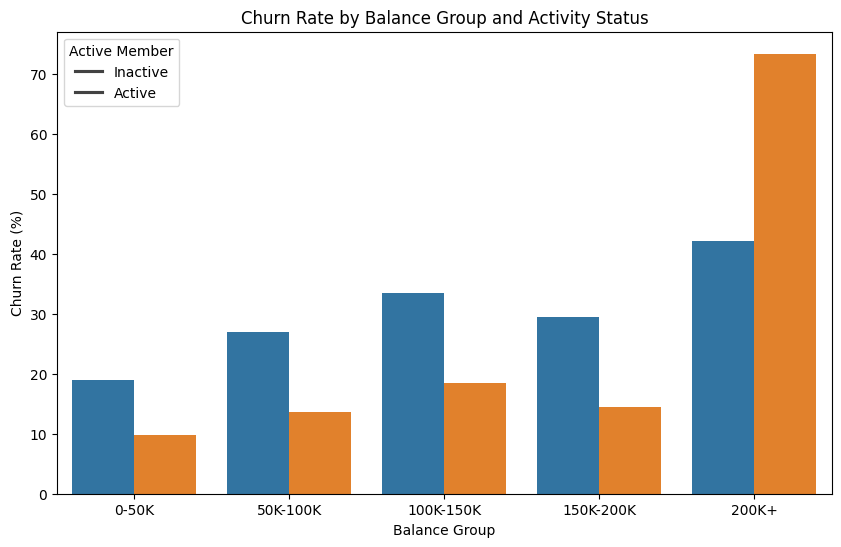

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=balance_activity_churn,
    x='BalanceGroup',
    y='Exited',
    hue='IsActiveMember'
)

plt.title('Churn Rate by Balance Group and Activity Status')
plt.xlabel('Balance Group')
plt.ylabel('Churn Rate (%)')
plt.legend(
    title='Active Member',
    labels=['Inactive', 'Active']
)

plt.show()

**Insight:**

Inactive customers generally show higher churn rates than active customers across the major balance segments up to 200K. However, the 200K+ segment shows an unusually high churn rate among active customers. Since this segment contains only 34 customers overall, further sample-size analysis is required before drawing a reliable conclusion.

In [68]:
balance_activity_summary = (
    df.groupby(['BalanceGroup', 'IsActiveMember'], observed=True)
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

balance_activity_summary['Churn_Rate'] *= 100

balance_activity_summary

,BalanceGroup,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate
0,0-50K,0,1779,338,18.999438
1,0-50K,1,1913,188,9.827496
2,50K-100K,0,714,192,26.890756
3,50K-100K,1,795,108,13.584906
4,100K-150K,0,1872,627,33.493590
5,100K-150K,1,1958,360,18.386108
6,150K-200K,0,465,137,29.462366
7,150K-200K,1,470,68,14.468085
8,200K+,0,19,8,42.105263
9,200K+,1,15,11,73.333333


**Insight:**

Customer activity is consistently associated with lower churn across balance segments up to 200K. The strongest difference is observed in the 100K–150K balance group, where churn is 33.49% among inactive customers compared with 18.39% among active customers. The 200K+ segment shows an unusual reversal, but its very small sample size limits the reliability of this observation.

In [69]:
#Step 21- Product vs Age

age_product_churn = (
    df.groupby(['AgeGroup', 'NumOfProducts'], observed=True)['Exited']
      .mean()
      .mul(100)
      .reset_index()
)

age_product_churn

,AgeGroup,NumOfProducts,Exited
0,18-25,1,9.824561
1,18-25,2,3.797468
2,18-25,3,60.000000
3,26-35,1,12.728344
4,26-35,2,2.630106
5,26-35,3,60.000000
6,26-35,4,100.000000
7,36-45,1,26.049516
8,36-45,2,7.780320
9,36-45,3,84.112150


In [72]:
age_product_summary = (
    df.groupby(['AgeGroup', 'NumOfProducts'], observed=True)
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)
age_product_summary['Churn_Rate'] *= 100


age_product_summary

,AgeGroup,NumOfProducts,Customer_Count,Churned_Customers,Churn_Rate
0,18-25,1,285,28,9.824561
1,18-25,2,316,12,3.797468
2,18-25,3,10,6,60.000000
3,26-35,1,1697,216,12.728344
4,26-35,2,1787,47,2.630106
5,26-35,3,50,30,60.000000
6,26-35,4,8,8,100.000000
7,36-45,1,1858,484,26.049516
8,36-45,2,1748,136,7.780320
9,36-45,3,107,90,84.112150


**Insight:**

The analysis shows a strong association between age, product usage and churn. Across the major age groups, customers with one product consistently have higher churn rates than customers with two products. The difference becomes particularly large among older customers: 46–55 customers with one product have a churn rate of 61.23%, compared with 21.21% among those with two products. Similarly, the 56–65 one-product segment has a churn rate of 54.81%. Small segments with three or four products show extremely high churn but should be interpreted cautiously because of their smaller sample sizes.

In [73]:
#Step 22- Correlation Analysis of Numerical Variables with Churn

numeric_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary',
    'Exited'
]

correlation = df[numeric_cols].corr()

correlation['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
Tenure,-0.014001
CreditScore,-0.027094
NumOfProducts,-0.047820


**Insight:**

Age has the strongest positive correlation with churn (0.285), indicating a moderate positive linear association between age and customer churn. Balance shows a weaker positive association (0.119). Estimated Salary, Tenure, Credit Score and Number of Products have very weak linear correlations with churn.

These results are broadly consistent with the earlier segmentation analyses, particularly the strong increase in churn among older customers. However, correlation measures only linear association and does not imply causation.

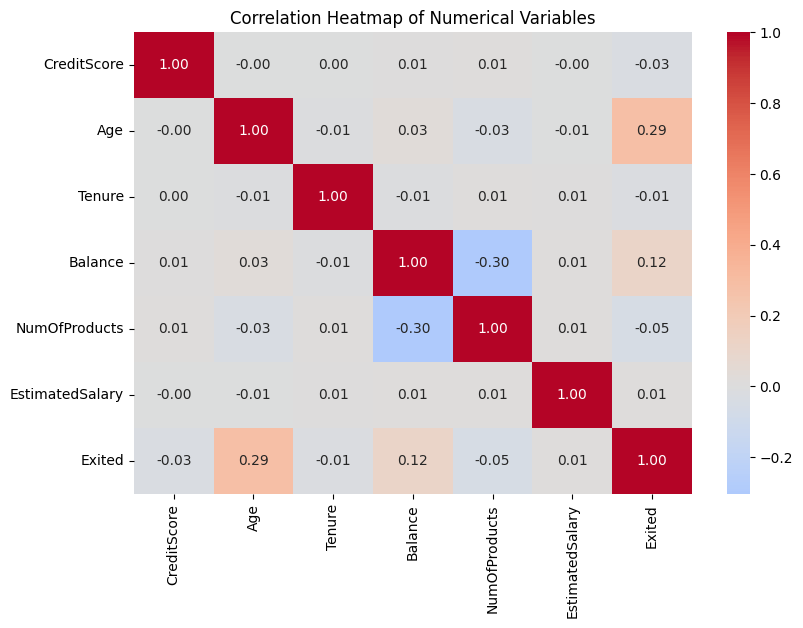

In [74]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Insight:**

- Age shows the strongest positive correlation with churn (0.29).
- Balance has a weak positive correlation with churn (0.12).
- Credit Score, Tenure, Number of Products and Estimated Salary show very weak linear relationships with churn.
- The correlation analysis supports the earlier finding that age is an important variable associated with customer churn.
- Correlation measures linear association only and should not be interpreted as evidence of causation.

In [75]:
#Step 23- Churn Driver Validation

overall_churn_rate = df['Exited'].mean() * 100

overall_churn_rate

np.float64(20.369999999999997)

In [76]:
overall_churn_rate = df['Exited'].mean() * 100

print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

Overall Churn Rate: 20.37%


In [77]:
#Step 23.1- Age Segment Risk

age_risk = age_group_summary.copy()

age_risk['Risk_vs_Overall'] = (
    age_risk['Churn_Rate'] / overall_churn_rate
)

age_risk['Difference_from_Overall'] = (
    age_risk['Churn_Rate'] - overall_churn_rate
)

age_risk

,AgeGroup,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
0,18-25,611,46,7.528642,0.369595,-12.841358
1,26-35,3542,301,8.498024,0.417183,-11.871976
2,36-45,3736,733,19.619914,0.963177,-0.750086
3,46-55,1311,663,50.572082,2.482675,30.202082
4,56-65,536,259,48.320896,2.372160,27.950896
5,66+,264,35,13.257576,0.650838,-7.112424


**Insight:**

Customers aged 46–55 and 56–65 represent the highest age-based churn risk. Their churn rates are 2.48× and 2.37× the overall churn rate of 20.37%, respectively. In contrast, customers below 36 years have churn rates substantially below the overall average. The 36–45 segment is close to the overall churn rate, suggesting that the sharp increase in churn is concentrated among customers aged 46 and above.

,AgeGroup,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
0,18-25,0,288,32,11.111111,0.545464,-9.258889
1,18-25,1,323,14,4.334365,0.212782,-16.035635
2,26-35,0,1740,188,10.804598,0.530417,-9.565402
3,26-35,1,1802,113,6.270810,0.307845,-14.099190
4,36-45,0,1945,471,24.215938,1.188804,3.845938
5,36-45,1,1791,262,14.628699,0.718149,-5.741301
6,46-55,0,665,423,63.609023,3.122682,43.239023
7,46-55,1,646,240,37.151703,1.823844,16.781703
8,56-65,0,179,168,93.854749,4.607499,73.484749
9,56-65,1,357,91,25.490196,1.251360,5.120196


In [79]:
activity_summary = (
    df.groupby('IsActiveMember')
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

activity_summary['Churn_Rate'] *= 100

activity_summary['Risk_vs_Overall'] = (
    activity_summary['Churn_Rate'] / overall_churn_rate
)

activity_summary['Difference_from_Overall'] = (
    activity_summary['Churn_Rate'] - overall_churn_rate
)

activity_summary

,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
0,0,4849,1302,26.850897,1.318159,6.480897
1,1,5151,735,14.269074,0.700495,-6.100926


**Insight:**

Customer activity is strongly associated with churn. Inactive customers have a churn rate of 26.85%, which is 6.48 percentage points higher than the overall churn rate of 20.37%. In comparison, active customers have a lower churn rate of 14.27%. This pattern suggests that inactive customers should be prioritized for retention efforts.

In [80]:
#Step 24- Geography vs Activity

geo_activity_summary = (
    df.groupby(['Geography', 'IsActiveMember'])
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

geo_activity_summary['Churn_Rate'] *= 100

geo_activity_summary['Risk_vs_Overall'] = (
    geo_activity_summary['Churn_Rate'] / overall_churn_rate
)

geo_activity_summary['Difference_from_Overall'] = (
    geo_activity_summary['Churn_Rate'] - overall_churn_rate
)

geo_activity_summary

,Geography,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
0,France,0,2423,512,21.130830,1.037350,0.760830
1,France,1,2591,298,11.501351,0.564622,-8.868649
2,Germany,0,1261,518,41.078509,2.016618,20.708509
3,Germany,1,1248,296,23.717949,1.164357,3.347949
4,Spain,0,1165,272,23.347639,1.146178,2.977639
5,Spain,1,1312,141,10.746951,0.527587,-9.623049


**Insight:**

Geography and customer activity together reveal that Germany is the highest-risk market. Inactive customers in Germany have a churn rate of 41.08%, approximately 2.02 times the overall churn rate of 20.37%. Even active customers in Germany have a churn rate of 23.72%, which is above the overall benchmark. In comparison, France and Spain show substantially lower churn among active customers. This suggests that Germany may require deeper investigation beyond customer activity alone.

In [81]:
#Step 25- Geography vs Gender vs Activity

geo_gender_activity = (
    df.groupby(['Geography', 'Gender', 'IsActiveMember'])
      .agg(
          Customer_Count=('Exited', 'size'),
          Churned_Customers=('Exited', 'sum'),
          Churn_Rate=('Exited', 'mean')
      )
      .reset_index()
)

geo_gender_activity['Churn_Rate'] *= 100

geo_gender_activity['Risk_vs_Overall'] = (
    geo_gender_activity['Churn_Rate'] / overall_churn_rate
)

geo_gender_activity['Difference_from_Overall'] = (
    geo_gender_activity['Churn_Rate'] - overall_churn_rate
)

geo_gender_activity.sort_values(
    'Churn_Rate',
    ascending=False
)

,Geography,Gender,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
4,Germany,Female,0,634,283,44.637224,2.191322,24.267224
6,Germany,Male,0,627,235,37.480064,1.839964,17.110064
5,Germany,Female,1,559,165,29.516995,1.449042,9.146995
8,Spain,Female,0,526,154,29.277567,1.437288,8.907567
0,France,Female,0,1099,288,26.205641,1.286482,5.835641
7,Germany,Male,1,689,131,19.013062,0.933385,-1.356938
10,Spain,Male,0,639,118,18.466354,0.906547,-1.903646
2,France,Male,0,1324,224,16.918429,0.830556,-3.451571
1,France,Female,1,1162,172,14.802065,0.726660,-5.567935
9,Spain,Female,1,563,77,13.676732,0.671415,-6.693268


**Insight:**

The combined analysis of geography, gender and activity identifies Germany’s inactive female customers as the highest-risk segment, with a churn rate of 44.64%, approximately 2.19 times the overall churn rate. Germany also shows elevated churn among inactive male customers (37.48%) and active female customers (29.52%). This indicates that Germany may require targeted retention strategies, with particular attention to inactive female customers.

In [86]:
#Step 26- Final High-Risk Segment


final_segment_analysis

final_segment_analysis = (
    df.groupby(
        ['AgeGroup', 'Geography', 'Gender', 'IsActiveMember']
    )
    .agg(
        Customer_Count=('Exited', 'size'),
        Churned_Customers=('Exited', 'sum'),
        Churn_Rate=('Exited', 'mean')
    )
    .reset_index()
)

final_segment_analysis['Churn_Rate'] *= 100

final_segment_analysis['Risk_vs_Overall'] = (
    final_segment_analysis['Churn_Rate'] / overall_churn_rate
)

final_segment_analysis['Difference_from_Overall'] = (
    final_segment_analysis['Churn_Rate'] - overall_churn_rate
)

final_segment_analysis.sort_values(
    ['Churn_Rate', 'Customer_Count'],
    ascending=[False, False]
)

pd.set_option('display.max_rows', None)

final_segment_analysis

/tmp/ipykernel_1222/4154471225.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,AgeGroup,Geography,Gender,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall,Difference_from_Overall
0,18-25,France,Female,0,63,5,7.936508,0.389617,-12.433492
1,18-25,France,Female,1,74,1,1.351351,0.066340,-19.018649
2,18-25,France,Male,0,79,6,7.594937,0.372849,-12.775063
3,18-25,France,Male,1,90,4,4.444444,0.218186,-15.925556
4,18-25,Germany,Female,0,36,8,22.222222,1.090929,1.852222
5,18-25,Germany,Female,1,32,3,9.375000,0.460236,-10.995000
6,18-25,Germany,Male,0,36,5,13.888889,0.681831,-6.481111
7,18-25,Germany,Male,1,39,0,0.000000,0.000000,-20.370000
8,18-25,Spain,Female,0,31,6,19.354839,0.950164,-1.015161
9,18-25,Spain,Female,1,36,4,11.111111,0.545464,-9.258889


**Insight:**

The four-dimensional segmentation highlights a highly concentrated churn risk among customers aged 46–55, particularly in Germany. Inactive German customers aged 46–55 show exceptionally high churn rates for both males (78.22%) and females (76.61%). Several other older German and French segments also exhibit elevated churn. However, very small segments with 100% churn should be interpreted cautiously. These findings suggest that retention strategies should prioritize older customers, particularly those in Germany, while investigating additional factors beyond activity status.

In [87]:
#Step 27- Segment Prioritization

priority_segments = final_segment_analysis[
    final_segment_analysis['Customer_Count'] >= 50
].copy()

priority_segments = priority_segments.sort_values(
    'Churned_Customers',
    ascending=False
)

priority_segments[
    [
        'AgeGroup',
        'Geography',
        'Gender',
        'IsActiveMember',
        'Customer_Count',
        'Churned_Customers',
        'Churn_Rate',
        'Risk_vs_Overall'
    ]
]

,AgeGroup,Geography,Gender,IsActiveMember,Customer_Count,Churned_Customers,Churn_Rate,Risk_vs_Overall
24,36-45,France,Female,0,426,107,25.117371,1.233057
28,36-45,Germany,Female,0,255,96,37.647059,1.848162
40,46-55,Germany,Female,0,124,95,76.612903,3.761065
36,46-55,France,Female,0,139,87,62.589928,3.072652
30,36-45,Germany,Male,0,245,86,35.102041,1.723222
26,36-45,France,Male,0,528,84,15.909091,0.781006
42,46-55,Germany,Male,0,101,79,78.217822,3.839854
38,46-55,France,Male,0,155,75,48.387097,2.375410
29,36-45,Germany,Female,1,195,63,32.307692,1.586043
25,36-45,France,Female,1,393,60,15.267176,0.749493


**Insight:**

Segment prioritization shows that churn risk and churn volume should both be considered when identifying retention targets. Customers aged 46–55 in Germany who are inactive represent the highest-risk segments, with churn rates above 76%. Meanwhile, the 36–45 France female inactive segment contributes the highest number of churned customers among the meaningful segments, with 107 churned customers. Therefore, retention priorities should balance segment risk with customer volume and actual churn contribution.

## Business Recommendations

1. **Prioritize the German market:** Germany shows the highest churn, particularly among inactive customers. Targeted retention strategies should be considered for this market.

2. **Focus on older customers:** Customers aged 46–65 have substantially higher churn rates than younger customers. Dedicated retention and early-warning strategies should be evaluated for these age groups.

3. **Re-engage inactive customers:** Inactive customers have a higher churn rate than active customers. Proactive engagement and personalized reactivation campaigns could be used to investigate and address potential churn risk.

4. **Investigate one-product customers:** One-product customers, especially in older age groups, show higher churn rates than two-product customers. The bank should investigate product suitability and relevant cross-sell opportunities.

5. **Use segment-based retention:** The highest-risk segments are concentrated among older and inactive customers, particularly in Germany. Retention efforts should prioritize customers based on both churn risk and potential business impact rather than using a one-size-fits-all approach.

6. **Investigate root causes:** EDA identifies associations but does not establish causation. Further analysis using customer behavior, transaction activity, service interactions, pricing/fees and product-level data would help identify the underlying causes of churn.

**KEY FINDINGS**

• Overall churn rate: 20.37%

• Age is a major churn indicator. Customers aged 46–55
  have the highest churn rate at 50.57%.

• Inactive customers show significantly higher churn
  (26.85%) than active customers (14.27%).

• Germany is the highest-risk geography, with inactive
  customers showing 41.08% churn.

• Female customers have higher churn (25.07%) than
  male customers (16.46%).

• One-product customers show higher churn than
  two-product customers, especially among older groups.

• The highest-risk segment is Germany + Age 46–55 +
  Inactive, with churn above 76% for both genders.

• Retention strategies should focus on high-risk
  customer segments rather than a one-size-fits-all approach.